In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
path="/content/drive/MyDrive/Data Science/Urban Air Pollution/"

In [17]:
train=pd.read_csv(path+'Train.csv')
test=pd.read_csv(path+'Test.csv')
sample_sub=pd.read_csv(path+'SampleSubmission.csv')

In [18]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train unique places:", train.Place_ID.nunique())
print("Test unique places:", test.Place_ID.nunique())
print("Overlap between train/test place ids:", len(set(train.Place_ID) & set(test.Place_ID)))
print(train['target'].describe())


Train shape: (30557, 82)
Test shape: (16136, 77)
Train unique places: 340
Test unique places: 179
Overlap between train/test place ids: 0
count    30557.000000
mean        61.148045
std         46.861309
min          1.000000
25%         25.000000
50%         50.000000
75%         80.000000
max        815.000000
Name: target, dtype: float64


In [19]:
train['source'] = 'train'
test['source'] = 'test'
all_data = pd.concat([train, test], ignore_index=True)

skip_keywords = ['azimuth', 'zenith', 'altitude', 'target']
profile_cols = [c for c in test.columns
                 if c not in ['Place_ID X Date', 'Date', 'Place_ID', 'source']
                 and not any(k in c for k in skip_keywords)]

print(f"Profiling {len(profile_cols)} columns per city")

city_profile = all_data.groupby('Place_ID')[profile_cols].agg(['mean', 'std'])
city_profile.columns = ['_'.join(col) for col in city_profile.columns]
city_profile = city_profile.reset_index()

# Track which cities are train vs test
city_source = all_data.groupby('Place_ID')['source'].first().reset_index()
city_profile = city_profile.merge(city_source, on='Place_ID')

print("City profile shape:", city_profile.shape)
city_profile.head()


Profiling 39 columns per city
City profile shape: (519, 80)


,Place_ID,precipitable_water_entire_atmosphere_mean,precipitable_water_entire_atmosphere_std,relative_humidity_2m_above_ground_mean,relative_humidity_2m_above_ground_std,specific_humidity_2m_above_ground_mean,specific_humidity_2m_above_ground_std,temperature_2m_above_ground_mean,temperature_2m_above_ground_std,u_component_of_wind_10m_above_ground_mean,u_component_of_wind_10m_above_ground_std,v_component_of_wind_10m_above_ground_mean,v_component_of_wind_10m_above_ground_std,L3_NO2_NO2_column_number_density_mean,L3_NO2_NO2_column_number_density_std,L3_NO2_NO2_slant_column_number_density_mean,L3_NO2_NO2_slant_column_number_density_std,L3_NO2_absorbing_aerosol_index_mean,L3_NO2_absorbing_aerosol_index_std,L3_NO2_cloud_fraction_mean,L3_NO2_cloud_fraction_std,L3_NO2_stratospheric_NO2_column_number_density_mean,L3_NO2_stratospheric_NO2_column_number_density_std,L3_NO2_tropopause_pressure_mean,L3_NO2_tropopause_pressure_std,...,L3_CLOUD_cloud_top_height_mean,L3_CLOUD_cloud_top_height_std,L3_CLOUD_cloud_top_pressure_mean,L3_CLOUD_cloud_top_pressure_std,L3_CLOUD_surface_albedo_mean,L3_CLOUD_surface_albedo_std,L3_AER_AI_absorbing_aerosol_index_mean,L3_AER_AI_absorbing_aerosol_index_std,L3_SO2_SO2_column_number_density_mean,L3_SO2_SO2_column_number_density_std,L3_SO2_SO2_column_number_density_amf_mean,L3_SO2_SO2_column_number_density_amf_std,L3_SO2_SO2_slant_column_number_density_mean,L3_SO2_SO2_slant_column_number_density_std,L3_SO2_absorbing_aerosol_index_mean,L3_SO2_absorbing_aerosol_index_std,L3_SO2_cloud_fraction_mean,L3_SO2_cloud_fraction_std,L3_CH4_CH4_column_volume_mixing_ratio_dry_air_mean,L3_CH4_CH4_column_volume_mixing_ratio_dry_air_std,L3_CH4_aerosol_height_mean,L3_CH4_aerosol_height_std,L3_CH4_aerosol_optical_depth_mean,L3_CH4_aerosol_optical_depth_std,source
0,010Q650,14.274552,5.133260,41.067022,17.631103,0.005980,0.001949,20.483771,3.414758,2.476054,0.751495,0.927223,1.743238,0.000064,0.000021,0.000146,0.000050,-0.718028,0.510701,0.065284,0.164766,0.000050,0.000016,8262.113779,3396.525933,...,3186.325096,2363.423424,72204.276756,19800.474730,0.252417,0.029629,-0.810368,0.484804,0.000036,0.000243,0.427888,0.158523,0.000014,0.000089,-1.296942,0.697033,0.089805,0.094637,1093.724798,896.674870,1963.473195,1615.684106,0.008459,0.008689,train
1,05EC30X,21.277033,6.669644,59.338890,18.244606,0.008652,0.002563,17.667414,2.835171,-1.552020,2.439405,-1.321987,2.468605,0.000057,0.000020,0.000128,0.000046,-1.202101,0.597672,0.257989,0.296113,0.000044,0.000014,7273.807977,2459.012689,...,3899.443553,2526.574283,66707.443045,17419.325391,0.283252,0.034433,-1.298696,0.495334,0.000031,0.000156,0.643256,0.211224,0.000020,0.000078,-2.035350,0.583118,0.157260,0.128699,952.423624,928.398655,1696.267910,1662.563051,0.012997,0.014899,train
2,0DPWHX8,12.583063,4.226884,80.236172,13.245295,0.004659,0.001101,5.891324,3.464863,0.516373,0.921251,0.474138,1.907226,0.000083,0.000045,0.000151,0.000063,-1.166821,0.592658,0.403601,0.364298,0.000032,0.000012,17662.096439,6031.697693,...,2721.169074,2007.531141,74669.089859,16660.317936,0.185718,0.026070,-1.231106,0.499999,0.000087,0.000517,0.318742,0.164204,0.000011,0.000128,-2.235594,0.676338,0.242597,0.183602,928.674786,955.631638,1654.370821,1716.223400,0.007865,0.015876,train
3,0GBXTHY,8.708063,3.304775,76.943618,9.084745,0.003248,0.000807,0.968610,2.564789,1.474192,4.909552,0.828765,2.334116,0.000042,0.000028,0.000127,0.000059,-1.067378,0.519581,0.404780,0.270399,0.000024,0.000014,18186.812282,7782.638989,...,5246.128191,3081.438302,55352.768638,19901.166885,0.440991,0.128185,-1.123056,0.410737,-0.000376,0.002729,0.219194,0.112863,-0.000032,0.000315,-2.074838,0.692077,0.327905,0.133032,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,train
4,0HYPV1N,37.563914,7.078002,73.253193,6.835734,0.015716,0.002007,26.330684,1.363422,-0.506712,0.769320,0.684031,1.796246,0.000071,0.000028,0.000128,0.000046,-1.315086,0.558509,0.134609,0.107499,0.000026,0.000009,6395.670821,2092.768094,...,2455.234987,1574.98

In [20]:
# Check missing
missing_pct = city_profile[[c for c in city_profile.columns if c not in ['Place_ID', 'source']]].isna().mean().sort_values(ascending=False)
print("Top 15 columns by missing %:")
print((missing_pct.head(15) * 100).round(1))

cluster_feature_cols = [c for c in city_profile.columns if c not in ['Place_ID', 'source']]

# Impute missing values median
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(city_profile[cluster_feature_cols])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("\nFinal clustering matrix shape:", X_scaled.shape)
print("Mean (should be ~0):", X_scaled.mean().round(3), "| Std (should be ~1):", X_scaled.std().round(3))


Top 15 columns by missing %:
L3_CH4_aerosol_height_std                             1.2
L3_CH4_CH4_column_volume_mixing_ratio_dry_air_std     1.2
L3_CH4_aerosol_optical_depth_std                      1.2
L3_SO2_cloud_fraction_mean                            0.2
L3_NO2_NO2_column_number_density_std                  0.2
L3_CH4_aerosol_optical_depth_mean                     0.2
L3_NO2_cloud_fraction_std                             0.2
L3_NO2_stratospheric_NO2_column_number_density_std    0.2
L3_NO2_absorbing_aerosol_index_std                    0.2
L3_NO2_tropospheric_NO2_column_number_density_std     0.2
L3_NO2_NO2_slant_column_number_density_std            0.2
L3_CH4_aerosol_height_mean                            0.2
L3_HCHO_cloud_fraction_std                            0.2
L3_HCHO_HCHO_slant_column_number_density_std          0.2
L3_SO2_absorbing_aerosol_index_std                    0.2
dtype: float64

Final clustering matrix shape: (519, 78)
Mean (should be ~0): 0.0 | Std (should be ~1

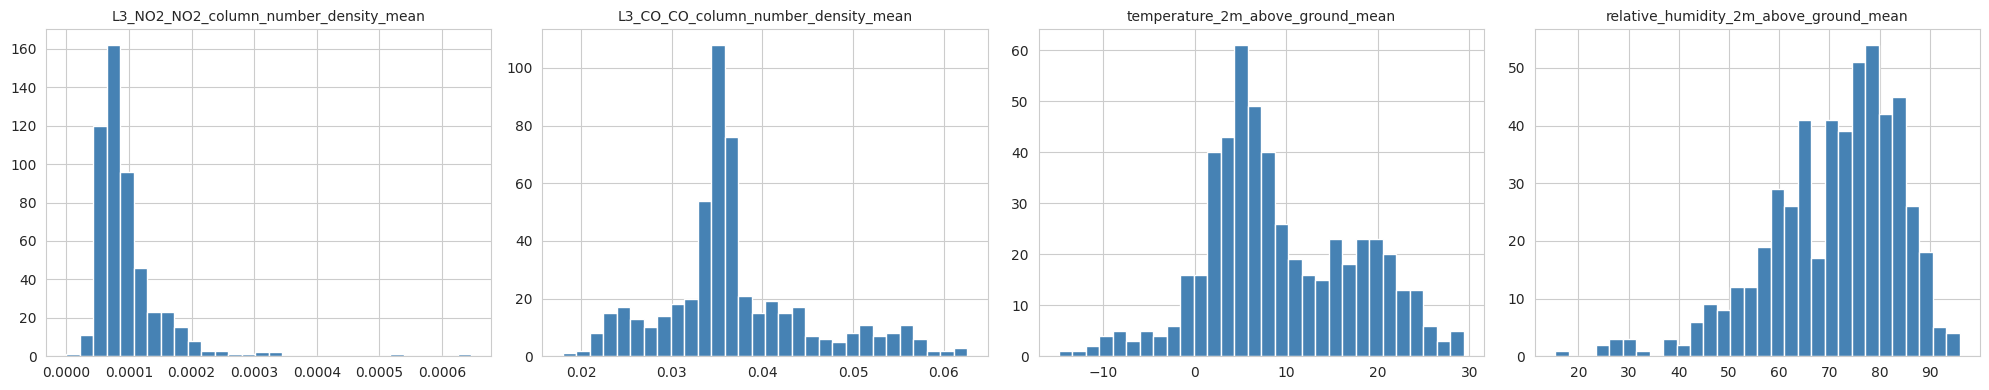

In [21]:
key_cols = ['L3_NO2_NO2_column_number_density_mean', 'L3_CO_CO_column_number_density_mean',
            'temperature_2m_above_ground_mean', 'relative_humidity_2m_above_ground_mean']
key_cols = [c for c in key_cols if c in city_profile.columns]

fig, axes = plt.subplots(1, len(key_cols), figsize=(5 * len(key_cols), 4))
for ax, col in zip(axes, key_cols):
    ax.hist(city_profile[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()


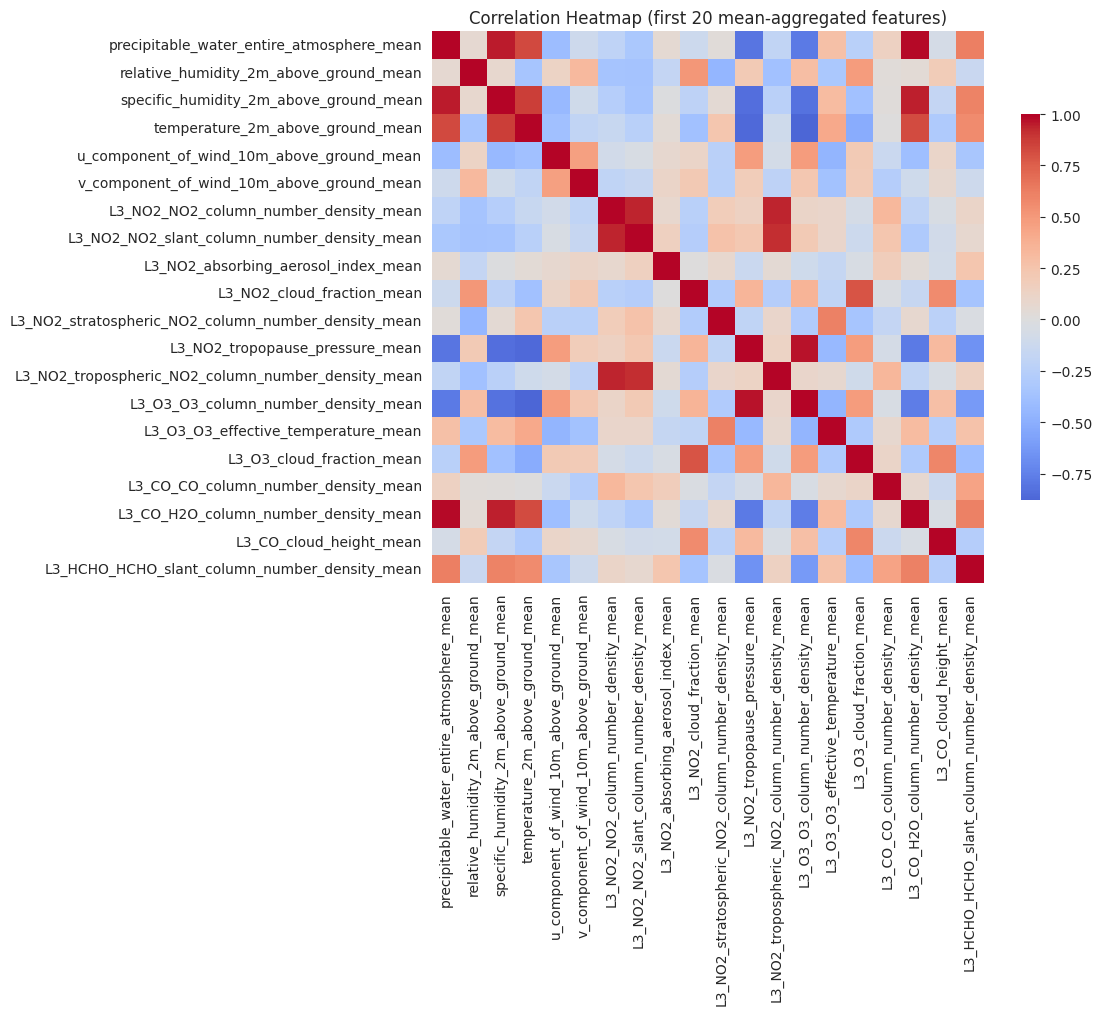

In [22]:
mean_cols = [c for c in cluster_feature_cols if c.endswith('_mean')][:20]
corr = city_profile[mean_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.7})
plt.title('Correlation Heatmap (first 20 mean-aggregated features)')
plt.tight_layout()
plt.show()


Number of components to explain 90% variance: 20
Variance explained by first 2 components: 35.53%


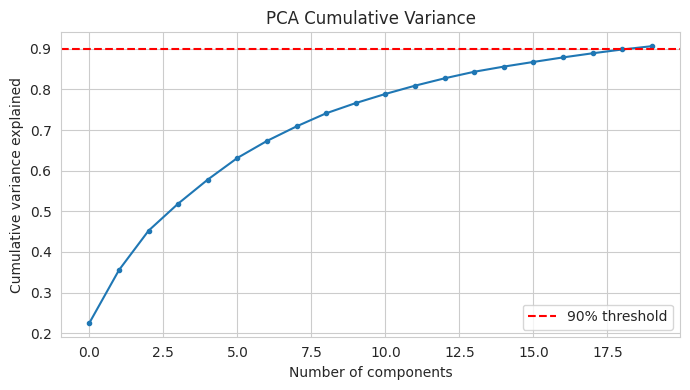

In [23]:
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Number of components to explain 90% variance: {X_pca.shape[1]}")
print(f"Variance explained by first 2 components: {pca.explained_variance_ratio_[:2].sum():.2%}")

# Cumulative variance plot
plt.figure(figsize=(7, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', markersize=3)
plt.axhline(0.9, color='red', linestyle='--', label='90% threshold')
plt.xlabel('Number of components')
plt.ylabel('Cumulative variance explained')
plt.title('PCA Cumulative Variance')
plt.legend()
plt.tight_layout()
plt.show()


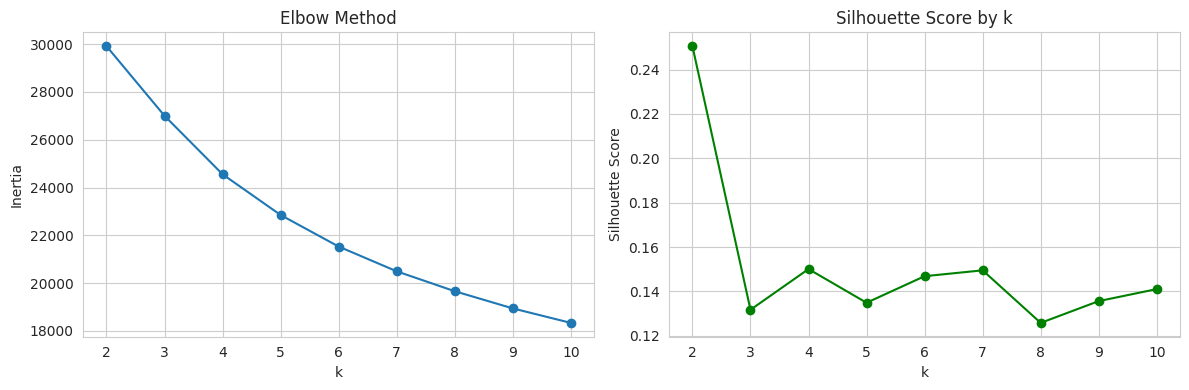

Best k by silhouette score: 2


In [24]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouettes, marker='o', color='green')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score'); axes[1].set_title('Silhouette Score by k')
plt.tight_layout()
plt.show()

best_k = k_range[np.argmax(silhouettes)]
print(f"Best k by silhouette score: {best_k}")


In [25]:
K_FINAL = best_k

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
city_profile['kmeans_cluster'] = kmeans_final.fit_predict(X_pca)

print(f"K-Means with k={K_FINAL}")
print(city_profile['kmeans_cluster'].value_counts().sort_index())
print(f"Silhouette score: {silhouette_score(X_pca, city_profile['kmeans_cluster']):.3f}")


K-Means with k=2
kmeans_cluster
0    155
1    364
Name: count, dtype: int64
Silhouette score: 0.251


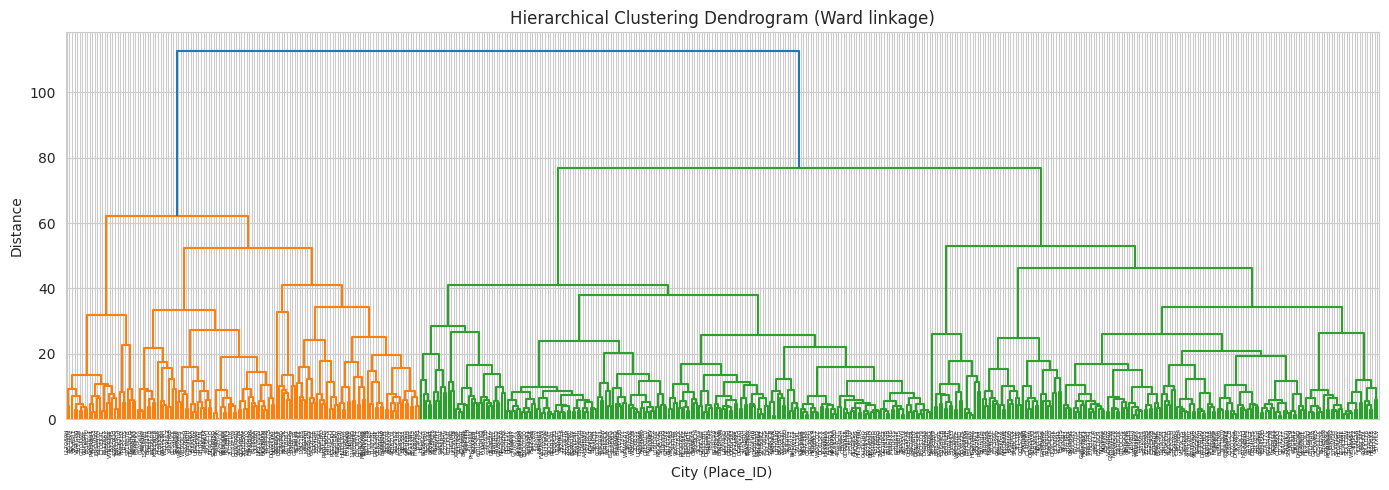

In [26]:
linkage_matrix = linkage(X_pca, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(linkage_matrix, labels=city_profile['Place_ID'].values, leaf_rotation=90, leaf_font_size=4)
plt.title('Hierarchical Clustering Dendrogram (Ward linkage)')
plt.xlabel('City (Place_ID)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


In [ ]:
agglo = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
city_profile['hierarchical_cluster'] = agglo.fit_predict(X_pca)

print(city_profile['hierarchical_cluster'].value_counts().sort_index())
print(f"Silhouette score: {silhouette_score(X_pca, city_profile['hierarchical_cluster']):.3f}")


print("\nCross-tab of K-Means vs Hierarchical cluster assignments:")
print(pd.crosstab(city_profile['kmeans_cluster'], city_profile['hierarchical_cluster']))


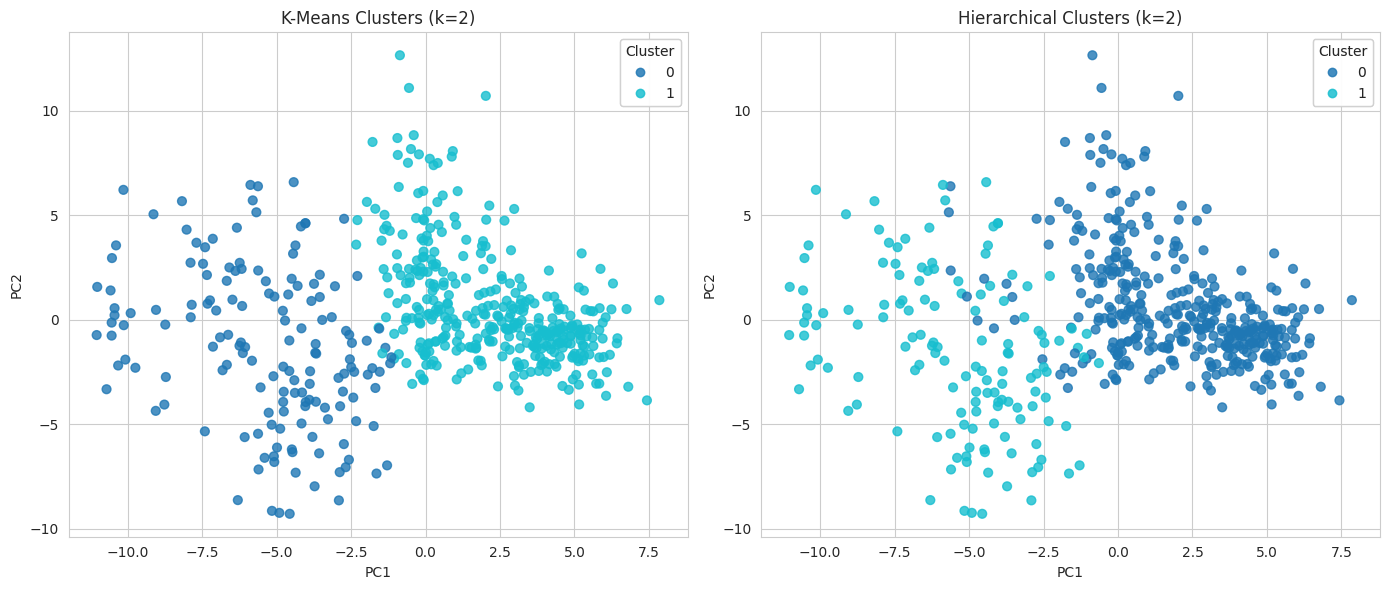

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=city_profile['kmeans_cluster'], cmap='tab10', s=40, alpha=0.8)
axes[0].set_title(f'K-Means Clusters (k={K_FINAL})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
legend1 = axes[0].legend(*scatter1.legend_elements(), title='Cluster', loc='best')
axes[0].add_artist(legend1)

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=city_profile['hierarchical_cluster'], cmap='tab10', s=40, alpha=0.8)
axes[1].set_title(f'Hierarchical Clusters (k={K_FINAL})')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
legend2 = axes[1].legend(*scatter2.legend_elements(), title='Cluster', loc='best')
axes[1].add_artist(legend2)

plt.tight_layout()
plt.show()


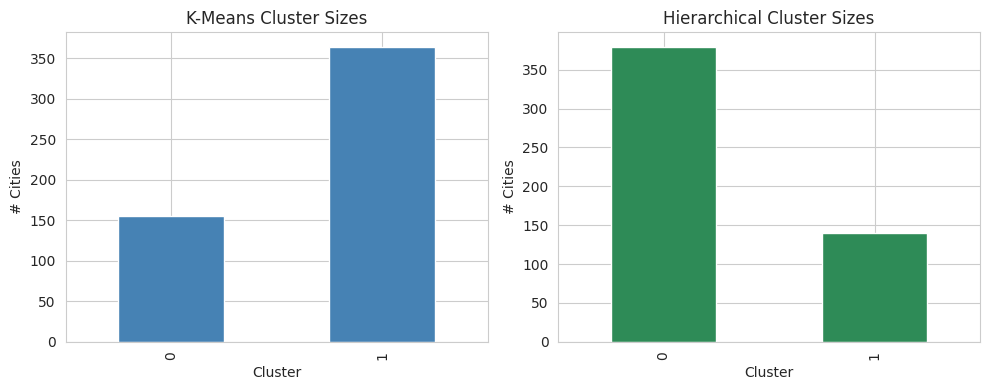

In [29]:
# Cluster sizes as a bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
city_profile['kmeans_cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('K-Means Cluster Sizes'); axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('# Cities')

city_profile['hierarchical_cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Hierarchical Cluster Sizes'); axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('# Cities')
plt.tight_layout()
plt.show()


In [30]:
print("=== Evaluation Metrics ===")
print(f"K-Means       -- Silhouette: {silhouette_score(X_pca, city_profile['kmeans_cluster']):.3f}  "
      f"| Davies-Bouldin: {davies_bouldin_score(X_pca, city_profile['kmeans_cluster']):.3f}")
print(f"Hierarchical  -- Silhouette: {silhouette_score(X_pca, city_profile['hierarchical_cluster']):.3f}  "
      f"| Davies-Bouldin: {davies_bouldin_score(X_pca, city_profile['hierarchical_cluster']):.3f}")
print("(Higher silhouette is better; lower Davies-Bouldin is better.)")


=== Evaluation Metrics ===
K-Means       -- Silhouette: 0.251  | Davies-Bouldin: 1.911
Hierarchical  -- Silhouette: 0.249  | Davies-Bouldin: 1.940
(Higher silhouette is better; lower Davies-Bouldin is better.)


In [31]:
interpret_cols = ['L3_NO2_NO2_column_number_density_mean', 'L3_CO_CO_column_number_density_mean',
                   'temperature_2m_above_ground_mean', 'relative_humidity_2m_above_ground_mean',
                   'u_component_of_wind_10m_above_ground_mean']
interpret_cols = [c for c in interpret_cols if c in city_profile.columns]

cluster_summary = city_profile.groupby('kmeans_cluster')[interpret_cols].mean().round(3)
cluster_summary['num_cities'] = city_profile.groupby('kmeans_cluster').size()
print("Average profile per K-Means cluster:")
print(cluster_summary)


Average profile per K-Means cluster:
                L3_NO2_NO2_column_number_density_mean  \
kmeans_cluster                                          
0                                                 0.0   
1                                                 0.0   

                L3_CO_CO_column_number_density_mean  \
kmeans_cluster                                        
0                                             0.036   
1                                             0.037   

                temperature_2m_above_ground_mean  \
kmeans_cluster                                     
0                                         19.023   
1                                          5.002   

                relative_humidity_2m_above_ground_mean  \
kmeans_cluster                                           
0                                               67.056   
1                                               72.436   

                u_component_of_wind_10m_above_ground_mean  num_cities  

In [32]:
cluster_map = city_profile.set_index('Place_ID')['kmeans_cluster'].to_dict()

train['city_cluster'] = train['Place_ID'].map(cluster_map)
test['city_cluster'] = test['Place_ID'].map(cluster_map)

print(train[['Place_ID', 'city_cluster']].drop_duplicates().head())
print("\nAny unmapped cities in train/test?",
      train['city_cluster'].isna().sum(), test['city_cluster'].isna().sum())


    Place_ID  city_cluster
0    010Q650             0
94   05EC30X             0
184  0DPWHX8             1
278  0GBXTHY             1
372  0HYPV1N             0

Any unmapped cities in train/test? 0 0


In [33]:
def add_date_features(df):
    df = df.copy()
    d = pd.to_datetime(df['Date'])
    df['day_of_year'] = d.dt.dayofyear
    df['month'] = d.dt.month
    df['day'] = d.dt.day
    df['weekday'] = d.dt.weekday
    df['week'] = d.dt.isocalendar().week.astype(int)
    return df

train = add_date_features(train)
test = add_date_features(test)

id_cols = ['Place_ID X Date', 'Date', 'Place_ID', 'source']
feature_cols = [c for c in test.columns if c not in id_cols]


skip_keywords_lag = ['azimuth', 'zenith', 'altitude']
date_part_cols = ['day_of_year', 'month', 'day', 'weekday', 'week', 'city_cluster']
lag_cols = [c for c in feature_cols if not any(k in c for k in skip_keywords_lag) and c not in date_part_cols]

def add_lag_features(df, cols, sort_col='Date', group_col='Place_ID'):
    df = df.sort_values([group_col, sort_col]).copy()
    g = df.groupby(group_col)
    for c in cols:
        df[f'{c}_lag1'] = g[c].shift(1)
        df[f'{c}_roll3_mean'] = g[c].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
        df[f'{c}_roll7_mean'] = g[c].transform(lambda s: s.shift(1).rolling(7, min_periods=1).mean())
    return df

train_lag = add_lag_features(train, lag_cols).sort_index()
test_lag = add_lag_features(test, lag_cols).sort_index()

# city baseline stats
def add_place_stats(df, cols, group_col='Place_ID'):
    df = df.copy()
    g = df.groupby(group_col)
    for c in cols:
        df[f'{c}_place_mean'] = g[c].transform('mean')
        df[f'{c}_place_std'] = g[c].transform('std')
        df[f'{c}_anomaly'] = df[c] - df[f'{c}_place_mean']
    return df

train_full = add_place_stats(train_lag, lag_cols)
test_full = add_place_stats(test_lag, lag_cols)

final_feature_cols = [c for c in test_full.columns if c not in id_cols]
X_full = train_full[final_feature_cols]
y_full = train_full['target']
groups_full = train_full['Place_ID'].values
X_test_full = test_full[final_feature_cols]

print("Final feature count (including city_cluster):", len(final_feature_cols))
print("X_full shape:", X_full.shape)


/tmp/ipykernel_834/2807225204.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{c}_lag1'] = g[c].shift(1)
/tmp/ipykernel_834/2807225204.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{c}_roll3_mean'] = g[c].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
/tmp/ipykernel_834/2807225204.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=

Final feature count (including city_cluster): 314
X_full shape: (30557, 314)


/tmp/ipykernel_834/2807225204.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{c}_place_mean'] = g[c].transform('mean')
/tmp/ipykernel_834/2807225204.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{c}_place_std'] = g[c].transform('std')
/tmp/ipykernel_834/2807225204.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented

In [ ]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

params = {
    'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.02,
    'num_leaves': 31, 'max_depth': -1, 'min_data_in_leaf': 20,
    'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 5,
    'lambda_l2': 1.0, 'verbose': -1,
}

oof_full = np.zeros(len(X_full))
test_preds_full = np.zeros(len(X_test_full))
fold_rmses_full = []
importances_full = np.zeros(len(final_feature_cols))

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_full, y_full, groups_full)):
    X_tr, X_val = X_full.iloc[tr_idx], X_full.iloc[val_idx]
    y_tr, y_val = y_full.iloc[tr_idx], y_full.iloc[val_idx]

    train_set = lgb.Dataset(X_tr, label=y_tr)
    val_set = lgb.Dataset(X_val, label=y_val, reference=train_set)

    model = lgb.train(params, train_set, num_boost_round=6000,
                       valid_sets=[val_set],
                       callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)])

    val_pred = np.clip(model.predict(X_val, num_iteration=model.best_iteration), 0, None)
    oof_full[val_idx] = val_pred

    test_pred = np.clip(model.predict(X_test_full, num_iteration=model.best_iteration), 0, None)
    test_preds_full += test_pred / N_SPLITS

    rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    fold_rmses_full.append(rmse)
    importances_full += model.feature_importance(importance_type='gain') / N_SPLITS
    print(f"Fold {fold}: RMSE = {rmse:.3f}, best_iter = {model.best_iteration}")

overall_rmse_full = np.sqrt(mean_squared_error(y_full, oof_full))
print(f"\nMean fold RMSE: {np.mean(fold_rmses_full):.3f} (+/- {np.std(fold_rmses_full):.3f})")
print(f"Overall OOF RMSE (with city_cluster feature): {overall_rmse_full:.3f}")

fi_full = pd.DataFrame({'feature': final_feature_cols, 'importance': importances_full}).sort_values('importance', ascending=False)
print("\nRank of 'city_cluster' feature:", (fi_full['feature'] == 'city_cluster').idxmax() if 'city_cluster' in fi_full['feature'].values else 'not found')
print(fi_full.head(15).to_string(index=False))


Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[4708]	valid_0's rmse: 34.8475
Fold 0: RMSE = 34.847, best_iter = 4708
Training until validation scores don't improve for 200 rounds


In [ ]:
submission = pd.DataFrame({
    'Place_ID X Date': test_full['Place_ID X Date'],
    'target': test_preds_full
})

print("Submission shape:", submission.shape)
print("Row count matches sample:", submission.shape[0] == sample_sub.shape[0])

missing_ids = set(sample_sub['Place_ID X Date']) - set(submission['Place_ID X Date'])
extra_ids = set(submission['Place_ID X Date']) - set(sample_sub['Place_ID X Date'])
print("Missing ids:", len(missing_ids), "| Extra ids:", len(extra_ids))

submission.to_csv('submission_with_clusters.csv', index=False)
print("Saved submission_with_clusters.csv")

from google.colab import files
files.download('submission_with_clusters.csv')
